In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import statsmodels.api as sms
from datetime import datetime

In [2]:
df=pd.read_csv('TATAMOTORS_data.csv')

In [3]:
df.head(3)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2017-11-15,414.299988,417.549988,407.000000,408.649994,408.649994,9867270
1,2017-11-16,411.350006,415.899994,411.350006,413.450012,413.450012,6291441
2,2017-11-17,419.450012,423.450012,417.000000,421.799988,421.799988,6191428


In [4]:
df.tail(3)

,Date,Open,High,Low,Close,Adj Close,Volume
1230,2022-11-09,439.200012,441.200012,432.000000,433.149994,433.149994,14471443
1231,2022-11-10,420.500000,420.549988,409.200012,412.200012,412.200012,26251660
1232,2022-11-11,420.000000,425.500000,414.700012,423.500000,423.500000,19296401


In [5]:
df.set_index('Date', inplace=True)
df

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2017-11-15,414.299988,417.549988,407.000000,408.649994,408.649994,9867270
2017-11-16,411.350006,415.899994,411.350006,413.450012,413.450012,6291441
2017-11-17,419.450012,423.450012,417.000000,421.799988,421.799988,6191428
2017-11-20,421.000000,425.700012,420.100006,423.000000,423.000000,4051153
2017-11-21,424.450012,430.000000,422.500000,424.250000,424.250000,6745407
...,...,...,...,...,...,...
2022-11-04,418.200012,426.000000,416.899994,425.350006,425.350006,12277023
2022-11-07,428.250000,437.500000,428.250000,435.000000,435.000000,15058076
2022-11-09,439.200012,441.200012,432.000000,433.149994,433.149994,14471443


In [6]:
# make it datetime format
df.index = pd.to_datetime(df.index, format = '%Y/%m/%d')

In [7]:
df.head(3)

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2017-11-15,414.299988,417.549988,407.000000,408.649994,408.649994,9867270
2017-11-16,411.350006,415.899994,411.350006,413.450012,413.450012,6291441
2017-11-17,419.450012,423.450012,417.000000,421.799988,421.799988,6191428


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1233 entries, 2017-11-15 to 2022-11-11
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       1233 non-null   float64
 1   High       1233 non-null   float64
 2   Low        1233 non-null   float64
 3   Close      1233 non-null   float64
 4   Adj Close  1233 non-null   float64
 5   Volume     1233 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 67.4 KB


In [9]:
df.shape

(1233, 6)

<AxesSubplot:xlabel='Date'>

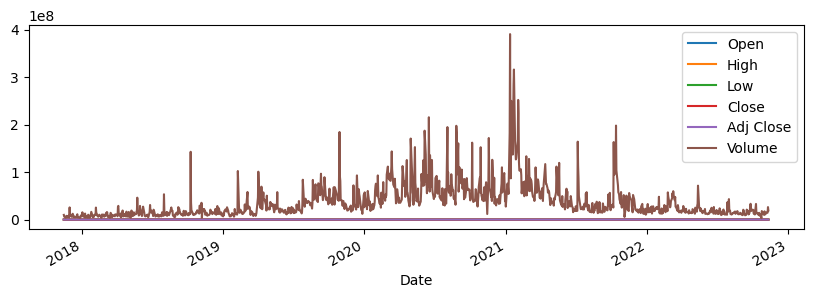

In [10]:
df.plot(figsize=(10,3))

<AxesSubplot:xlabel='Date'>

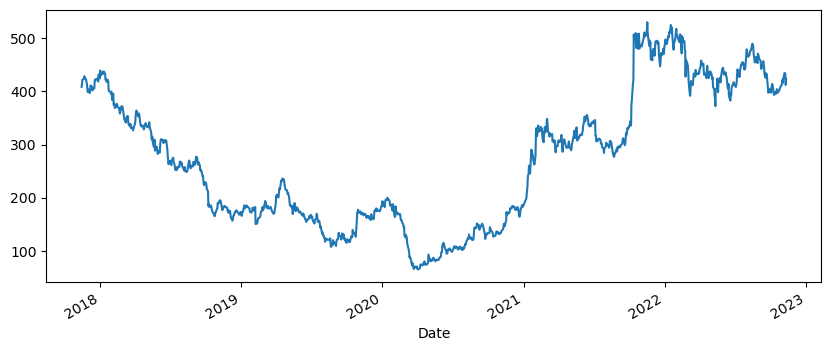

In [11]:
df['Close'].plot(figsize=(10,4))

<AxesSubplot:xlabel='Date'>

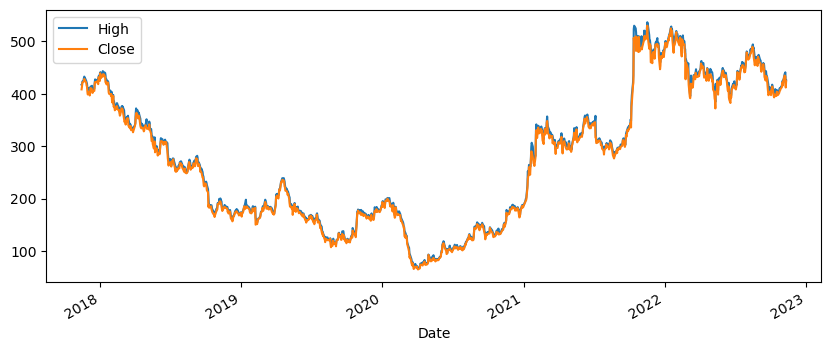

In [12]:
df[['High','Close']].plot(figsize=(10,4))

<AxesSubplot:xlabel='Date'>

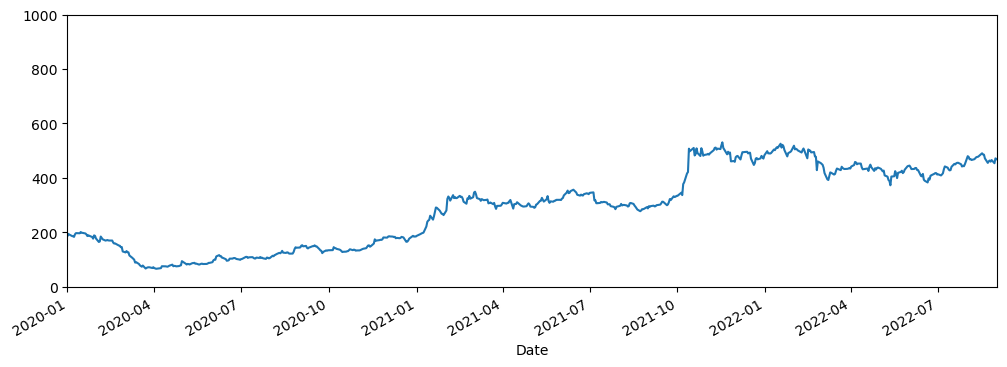

In [13]:
df['Close'].plot(xlim=['2020-01-01','2022-09-01'],ylim=[0,1000],figsize=(12,4))

In [14]:
df.index

DatetimeIndex(['2017-11-15', '2017-11-16', '2017-11-17', '2017-11-20',
               '2017-11-21', '2017-11-22', '2017-11-23', '2017-11-24',
               '2017-11-27', '2017-11-28',
               ...
               '2022-10-28', '2022-10-31', '2022-11-01', '2022-11-02',
               '2022-11-03', '2022-11-04', '2022-11-07', '2022-11-09',
               '2022-11-10', '2022-11-11'],
              dtype='datetime64[ns]', name='Date', length=1233, freq=None)

# Time Resampling

In [15]:
df.resample(rule='A').min() 
#It gives us MIN values of all parameters in each year.

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2017-12-31,398.000000,404.000000,389.299988,397.049988,397.049988,3673355
2018-12-31,155.000000,159.500000,154.649994,157.100006,157.100006,3820313
2019-12-31,108.900002,111.599998,106.000000,107.699997,107.699997,6141180
2020-12-31,66.500000,66.900002,63.500000,65.300003,65.300003,11749453
2021-12-31,184.949997,187.000000,184.500000,186.500000,186.500000,5531940
2022-12-31,382.000000,384.649994,366.200012,372.299988,372.299988,2871205


In [16]:
df.resample(rule='A').max()  
#It gives us MAX values of all parameters in each year.

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2017-12-31,428.600006,433.450012,424.500000,431.850006,431.850006,25646262
2018-12-31,440.399994,443.500000,433.000000,439.299988,439.299988,142760251
2019-12-31,235.000000,239.350006,231.699997,236.250000,236.250000,184435614
2020-12-31,199.500000,201.699997,196.899994,200.350006,200.350006,215476711
2021-12-31,531.450012,536.700012,520.250000,530.150024,530.150024,390577839
2022-12-31,527.900024,528.500000,512.000000,525.000000,525.000000,71425747


<AxesSubplot:xlabel='Date'>

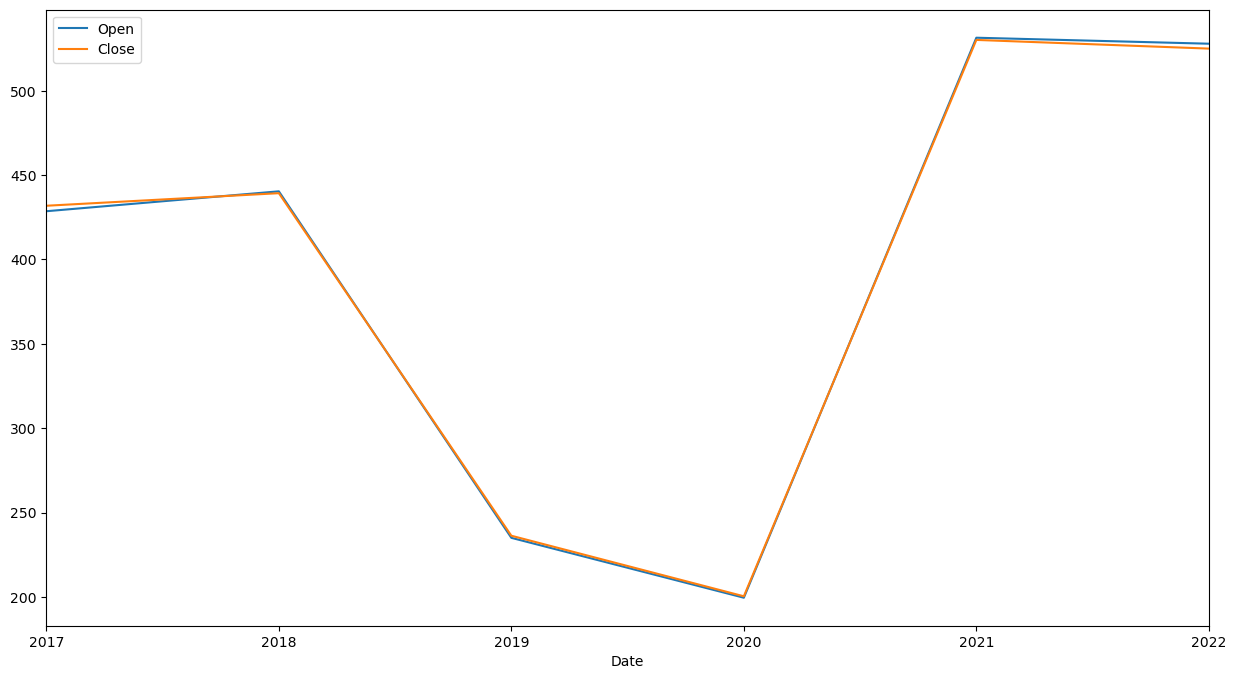

In [17]:
##rule = A : year end frequency
df.resample(rule='A').max()[['Open','Close']].plot(figsize=(15,8))
# PLOT open max price over the year

In [18]:
df.resample(rule='QS').max()
##RULE QS : quaterly start frequency--> after three months

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2017-10-01,428.600006,433.450012,424.500000,431.850006,431.850006,25646262
2018-01-01,440.399994,443.500000,433.000000,439.299988,439.299988,25294860
2018-04-01,362.600006,372.350006,359.799988,364.100006,364.100006,46104103
2018-07-01,277.250000,282.000000,272.899994,277.399994,277.399994,53282545
2018-10-01,230.000000,232.800003,225.800003,229.350006,229.350006,142760251
2019-01-01,195.399994,198.350006,187.800003,194.050003,194.050003,102256857
2019-04-01,235.000000,239.350006,231.699997,236.250000,236.250000,100834335
2019-07-01,170.000000,172.350006,166.300003,170.000000,170.000000,96568372
2019-10-01,184.000000,187.899994,181.550003,185.149994,185.149994,184435614


<AxesSubplot:xlabel='Date'>

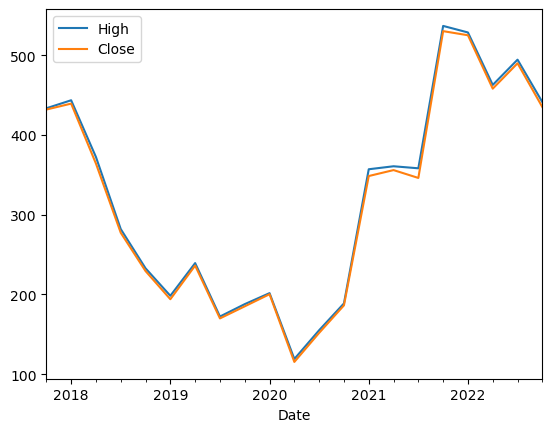

In [19]:
##RULE QS : quaterly start frequency--> after three months 
##https://towardsdatascience.com/resample-function-of-pandas-79b17ec82a78
df.resample(rule='QS').max()[['High','Close']].plot()

In [20]:
##RULE BA : Business End Frequency
##https://towardsdatascience.com/resample-function-of-pandas-79b17ec82a78
df.resample(rule='BA').max()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2017-12-29,428.600006,433.450012,424.500000,431.850006,431.850006,25646262
2018-12-31,440.399994,443.500000,433.000000,439.299988,439.299988,142760251
2019-12-31,235.000000,239.350006,231.699997,236.250000,236.250000,184435614
2020-12-31,199.500000,201.699997,196.899994,200.350006,200.350006,215476711
2021-12-31,531.450012,536.700012,520.250000,530.150024,530.150024,390577839
2022-12-30,527.900024,528.500000,512.000000,525.000000,525.000000,71425747


In [21]:
df.resample(rule='BQS').max()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2017-10-02,428.600006,433.450012,424.500000,431.850006,431.850006,25646262
2018-01-01,440.399994,443.500000,433.000000,439.299988,439.299988,25294860
2018-04-02,362.600006,372.350006,359.799988,364.100006,364.100006,46104103
2018-07-02,277.250000,282.000000,272.899994,277.399994,277.399994,53282545
2018-10-01,230.000000,232.800003,225.800003,229.350006,229.350006,142760251
2019-01-01,195.399994,198.350006,187.800003,194.050003,194.050003,102256857
2019-04-01,235.000000,239.350006,231.699997,236.250000,236.250000,100834335
2019-07-01,170.000000,172.350006,166.300003,170.000000,170.000000,96568372
2019-10-01,184.000000,187.899994,181.550003,185.149994,185.149994,184435614


<AxesSubplot:xlabel='Date'>

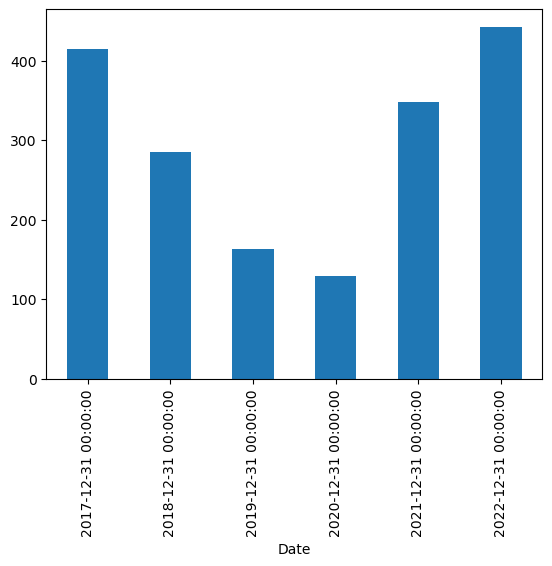

In [22]:
##plotting
df['Close'].resample(rule='A').mean().plot(kind='bar')

<AxesSubplot:xlabel='Date'>

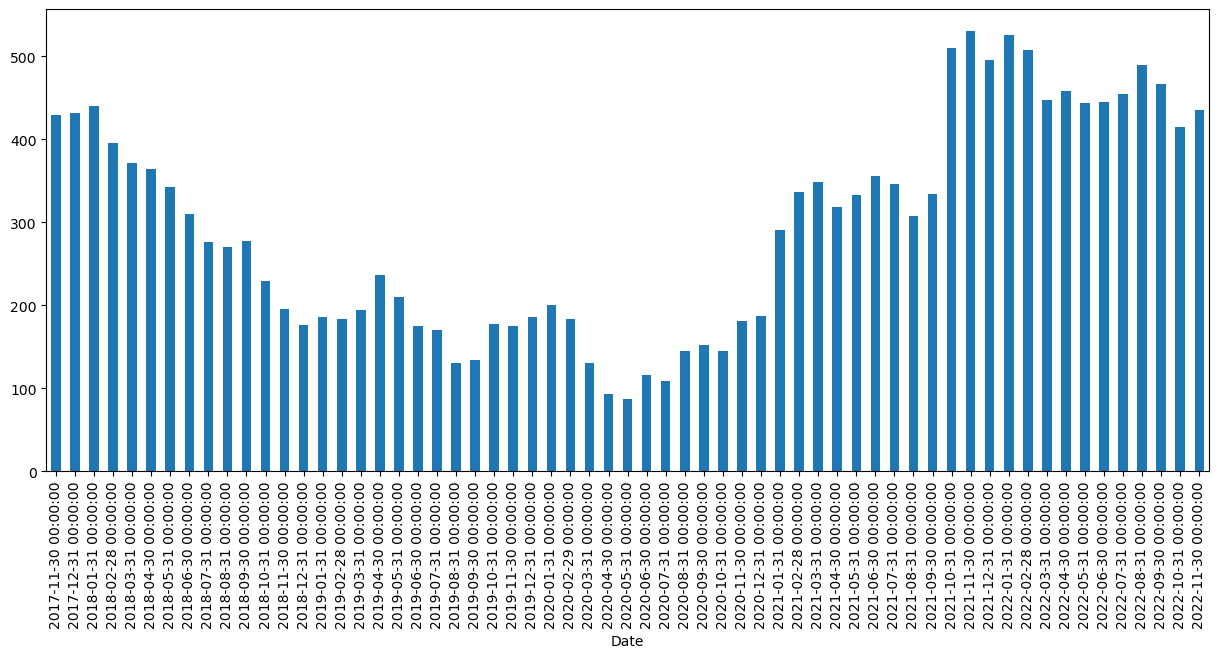

In [23]:
# RULE M : monthly data
df['Close'].resample(rule='M').max().plot(kind='bar',figsize=(15,6))

In [24]:
df['Close'].rolling(11).mean().head(20)

Date
2017-11-15           NaN
2017-11-16           NaN
2017-11-17           NaN
2017-11-20           NaN
2017-11-21           NaN
2017-11-22           NaN
2017-11-23           NaN
2017-11-24           NaN
2017-11-27           NaN
2017-11-28           NaN
2017-11-29    420.254547
2017-11-30    419.845456
2017-12-01    418.522727
2017-12-04    416.872728
2017-12-05    414.986364
2017-12-06    412.513636
2017-12-07    410.095453
2017-12-08    408.722726
2017-12-11    407.327271
2017-12-12    406.004544
Name: Close, dtype: float64

In [25]:
df['Close'].rolling(11).max().head(20)

Date
2017-11-15           NaN
2017-11-16           NaN
2017-11-17           NaN
2017-11-20           NaN
2017-11-21           NaN
2017-11-22           NaN
2017-11-23           NaN
2017-11-24           NaN
2017-11-27           NaN
2017-11-28           NaN
2017-11-29    428.600006
2017-11-30    428.600006
2017-12-01    428.600006
2017-12-04    428.600006
2017-12-05    428.600006
2017-12-06    428.600006
2017-12-07    426.250000
2017-12-08    425.500000
2017-12-11    421.399994
2017-12-12    415.950012
Name: Close, dtype: float64

In [26]:
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2017-11-15,414.299988,417.549988,407.000000,408.649994,408.649994,9867270
2017-11-16,411.350006,415.899994,411.350006,413.450012,413.450012,6291441
2017-11-17,419.450012,423.450012,417.000000,421.799988,421.799988,6191428
2017-11-20,421.000000,425.700012,420.100006,423.000000,423.000000,4051153
2017-11-21,424.450012,430.000000,422.500000,424.250000,424.250000,6745407


In [27]:
# simple moving average
df['Close:2 days rolling']=df['Close'].rolling(2).mean()
df['Close:5 days rolling']=df['Close'].rolling(5).mean()
df['Close:7 days rolling']=df['Close'].rolling(7).mean()
df['Close:10 days rolling']=df['Close'].rolling(10).mean()
df['Close:30 days rolling']=df['Close'].rolling(30).mean()
df['Close:50 days rolling']=df['Close'].rolling(50).mean()

In [28]:
df.head(31)

,Open,High,Low,Close,Adj Close,Volume,Close:2 days rolling,Close:5 days rolling,Close:7 days rolling,Close:10 days rolling,Close:30 days rolling,Close:50 days rolling
Date,,,,,,,,,,,,
2017-11-15,414.299988,417.549988,407.000000,408.649994,408.649994,9867270,NaN,NaN,NaN,NaN,NaN,NaN
2017-11-16,411.350006,415.899994,411.350006,413.450012,413.450012,6291441,411.050003,NaN,NaN,NaN,NaN,NaN
2017-11-17,419.450012,423.450012,417.000000,421.799988,421.799988,6191428,417.625000,NaN,NaN,NaN,NaN,NaN
2017-11-20,421.000000,425.700012,420.100006,423.000000,423.000000,4051153,422.399994,NaN,NaN,NaN,NaN,NaN
2017-11-21,424.450012,430.000000,422.500000,424.250000,424.250000,6745407,423.625000,418.229999,NaN,NaN,NaN,NaN
2017-11-22,425.450012,433.000000,424.500000,428.600006,428.600006,7899417,426.425003,422.220001,NaN,NaN,NaN,NaN
2017-11-23,428.600006,431.049988,422.450012,426.250000,426.250000,7374216,427.425003,424.779999,420.857143,NaN,NaN,NaN
2017-11-24,427.000000,429.950012,424.250000,425.500000,425.500000,5108182,425.875000,425.520001,423.264287,NaN,NaN,NaN
2017-11-27,423.000000,424.750000,417.799988,421.399994,421.399994,7946028,423.449997,425.200000,424.399998,NaN,NaN,NaN


<AxesSubplot:xlabel='Date'>

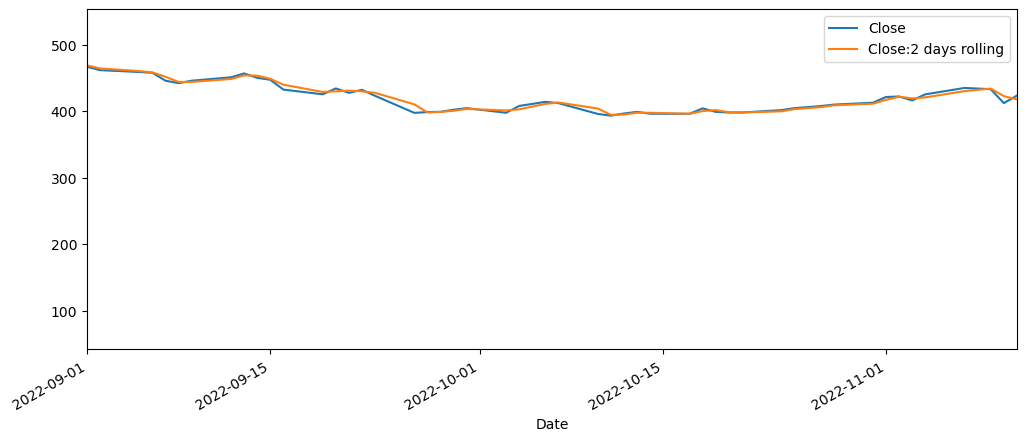

In [29]:
df[['Close','Close:2 days rolling']].plot(xlim=['2022-09-01','2022-11-11'],figsize=(12,5))

<AxesSubplot:xlabel='Date'>

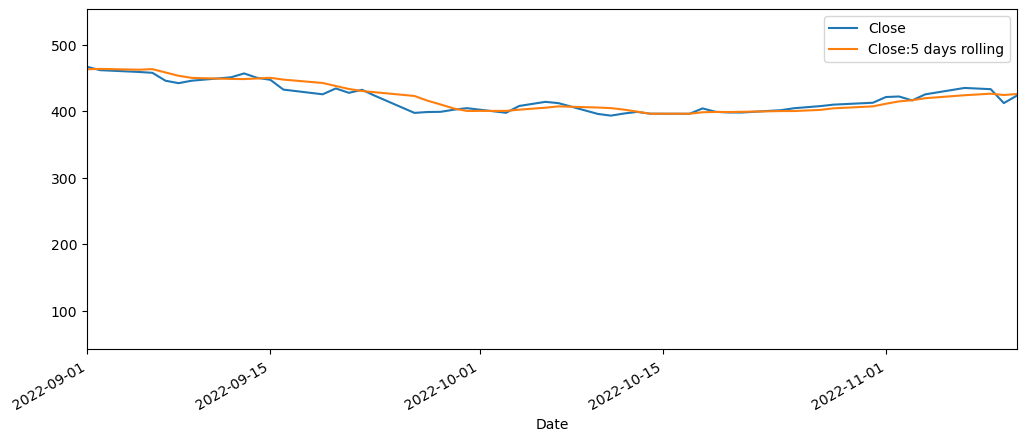

In [30]:
df[['Close','Close:5 days rolling']].plot(xlim=['2022-09-01','2022-11-11'],figsize=(12,5))

<AxesSubplot:xlabel='Date'>

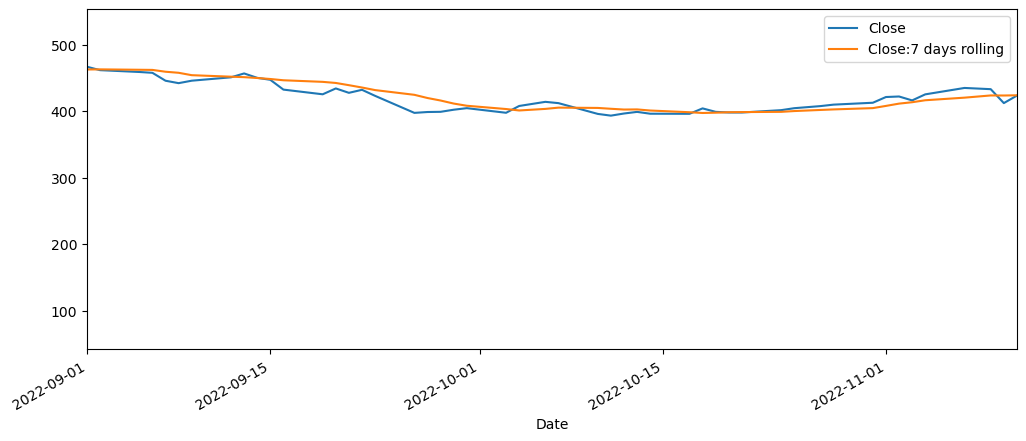

In [31]:
df[['Close','Close:7 days rolling']].plot(xlim=['2022-09-01','2022-11-11'],figsize=(12,5))

<AxesSubplot:xlabel='Date'>

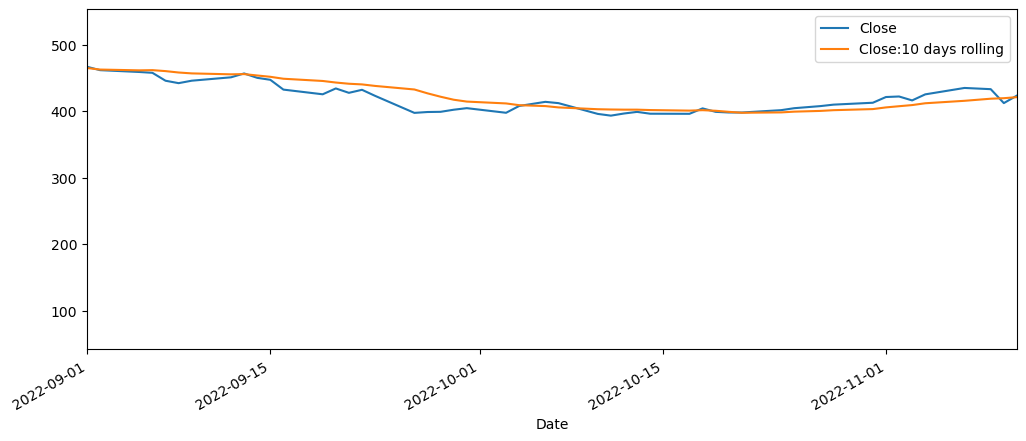

In [32]:
df[['Close','Close:10 days rolling']].plot(xlim=['2022-09-01','2022-11-11'],figsize=(12,5))

<AxesSubplot:xlabel='Date'>

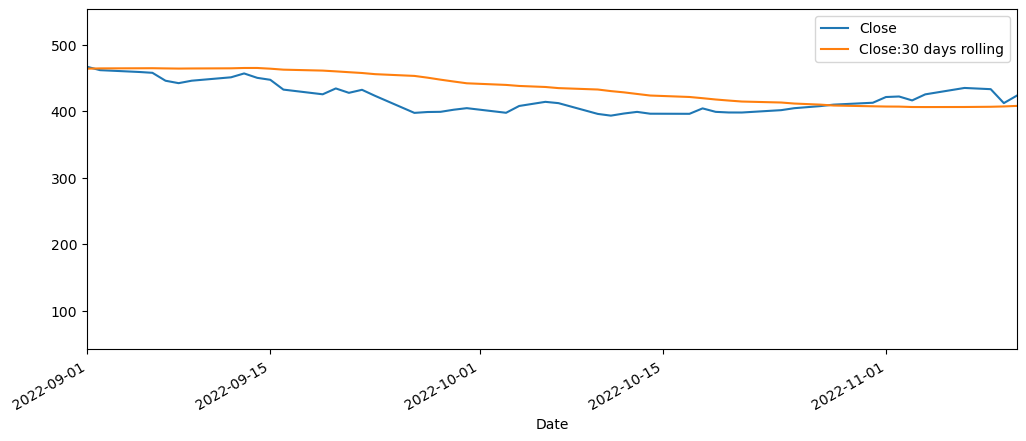

In [33]:
df[['Close','Close:30 days rolling']].plot(xlim=['2022-09-01','2022-11-11'],figsize=(12,5))

<AxesSubplot:xlabel='Date'>

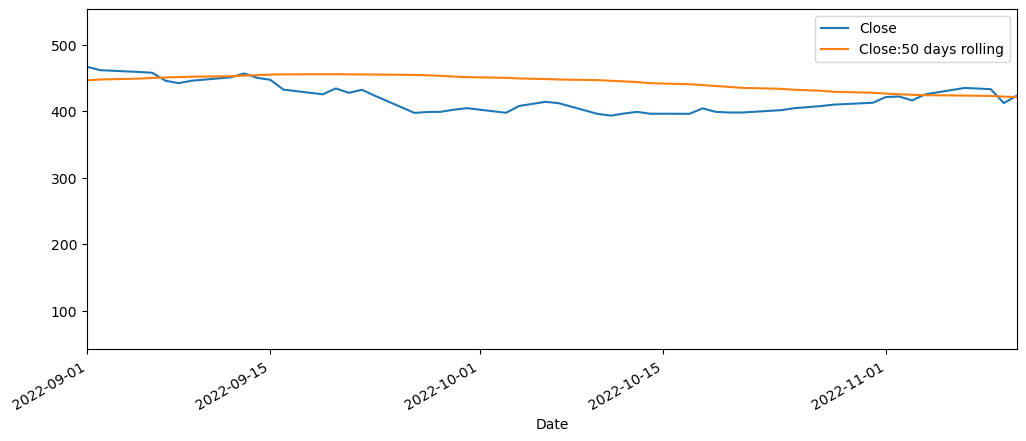

In [34]:
df[['Close','Close:50 days rolling']].plot(xlim=['2022-09-01','2022-11-11'],figsize=(12,5))

<AxesSubplot:xlabel='Date'>

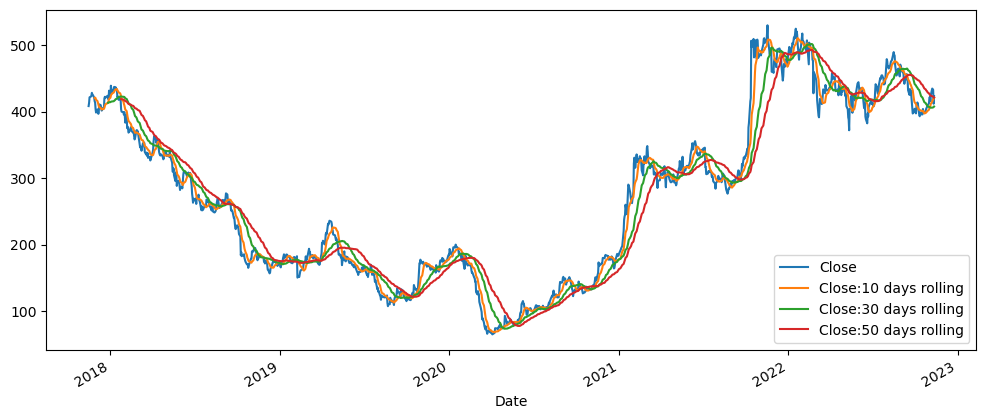

In [35]:
df[['Close','Close:10 days rolling','Close:30 days rolling','Close:50 days rolling']].plot(figsize=(12,5))

<AxesSubplot:xlabel='Date'>

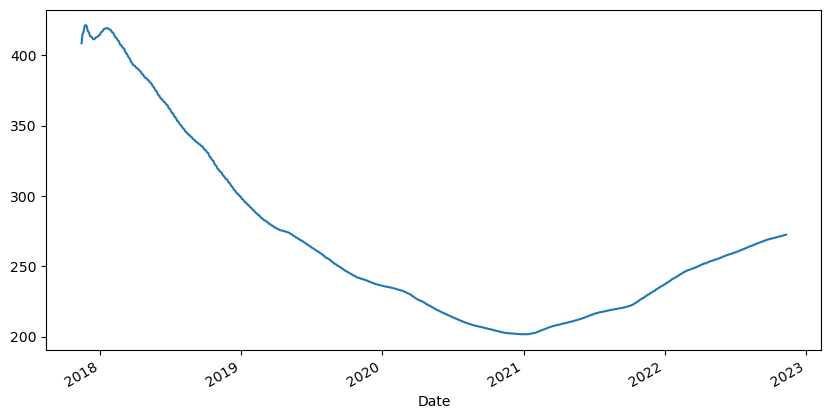

In [36]:
# cumulative moving average(here I use for only open stock)
# use expanding
df['Close'].expanding().mean().plot(figsize=(10,5))

In [37]:
#  exponential moving average
df['EMA_0.1'] = df['Close'].ewm(alpha=0.1, adjust=False).mean()
df['EMA_0.3'] = df['Close'].ewm(alpha=0.3, adjust=False).mean()

<AxesSubplot:xlabel='Date'>

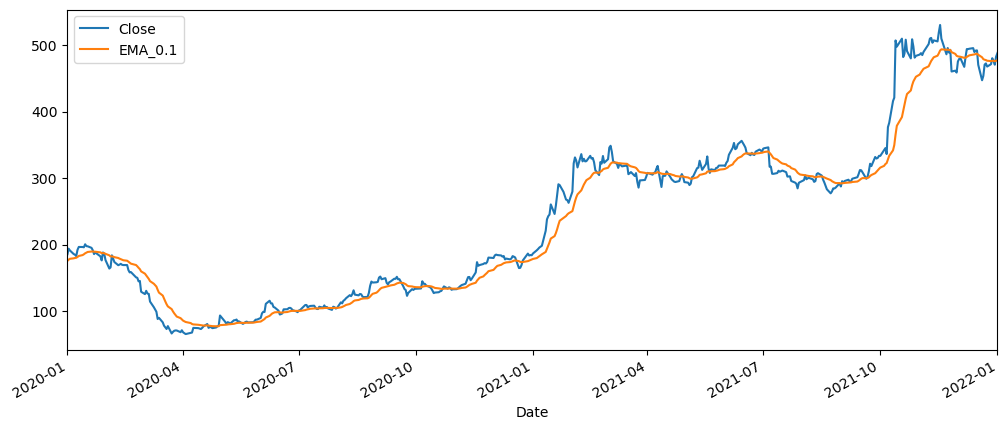

In [38]:
df[['Close','EMA_0.1']].plot(xlim=['2020-01-01','2022-01-01'],figsize=(12,5))

<AxesSubplot:xlabel='Date'>

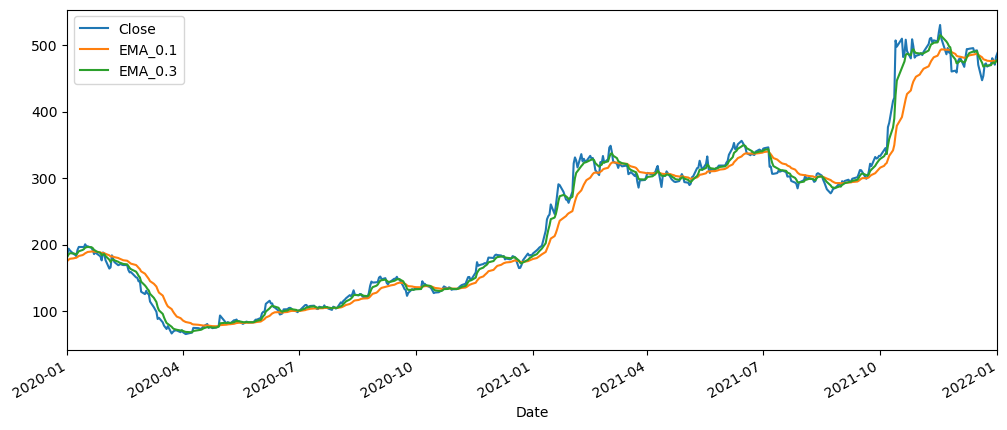

In [39]:
df[['Close','EMA_0.1','EMA_0.3']].plot(xlim=['2020-01-01','2022-01-01'],figsize=(12,5))

# STAT MODEL WITH ARIMA

In [40]:
# since it is seasonal data we are going to use dickey fuller test
from statsmodels.tsa.stattools import adfuller

In [41]:
# H0 : It is not stationary
# H1 : It is stationary

In [42]:
def adf_test(series):
    result=adfuller(series)
    print('ADF Statistics: {}'.format(result[0]))
    print('p- value: {}'.format(result[1]))
    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")

#strong evidence against the null hypothesis, reject the null hypothesis. 
#Data has no unit root and is stationary

#weak evidence against null hypothesis, time series has a unit root, 
#indicating it is non-stationary 

In [43]:
df1=pd.read_csv('TATAMOTORS_data.csv')
df1.head(3)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2017-11-15,414.299988,417.549988,407.000000,408.649994,408.649994,9867270
1,2017-11-16,411.350006,415.899994,411.350006,413.450012,413.450012,6291441
2,2017-11-17,419.450012,423.450012,417.000000,421.799988,421.799988,6191428


In [44]:
df1.shape

(1233, 7)

In [45]:
df1.set_index('Date', inplace=True)

In [46]:
df1.index = pd.to_datetime(df.index, format = '%Y/%m/%d')

In [47]:
df1

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2017-11-15,414.299988,417.549988,407.000000,408.649994,408.649994,9867270
2017-11-16,411.350006,415.899994,411.350006,413.450012,413.450012,6291441
2017-11-17,419.450012,423.450012,417.000000,421.799988,421.799988,6191428
2017-11-20,421.000000,425.700012,420.100006,423.000000,423.000000,4051153
2017-11-21,424.450012,430.000000,422.500000,424.250000,424.250000,6745407
...,...,...,...,...,...,...
2022-11-04,418.200012,426.000000,416.899994,425.350006,425.350006,12277023
2022-11-07,428.250000,437.500000,428.250000,435.000000,435.000000,15058076
2022-11-09,439.200012,441.200012,432.000000,433.149994,433.149994,14471443


In [48]:
adf_test(df1['Close'])

ADF Statistics: -1.1490244440559358
p- value: 0.6951311109960278
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 


In [49]:
## Use Techniques Differencing --> 
# one dayy differencing to convery into stationary data
# we can;t work with seasonal data
df1['first_diff_Close']=df1['Close']-df1['Close'].shift(1)

In [50]:
df1.head()

,Open,High,Low,Close,Adj Close,Volume,first_diff_Close
Date,,,,,,,
2017-11-15,414.299988,417.549988,407.000000,408.649994,408.649994,9867270,NaN
2017-11-16,411.350006,415.899994,411.350006,413.450012,413.450012,6291441,4.800018
2017-11-17,419.450012,423.450012,417.000000,421.799988,421.799988,6191428,8.349976
2017-11-20,421.000000,425.700012,420.100006,423.000000,423.000000,4051153,1.200012
2017-11-21,424.450012,430.000000,422.500000,424.250000,424.250000,6745407,1.250000


In [51]:
adf_test(df1['first_diff_Close'].dropna())

ADF Statistics: -9.125982827214441
p- value: 3.112876744456458e-15
strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary


In [52]:
# now time to determine p(pacf) and q(acf) value
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

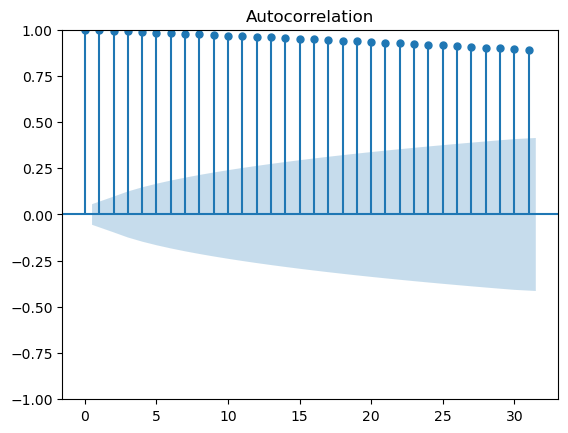

In [53]:
acf = plot_acf(df1["Close"].dropna())

C:\Users\BIPLAB\anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


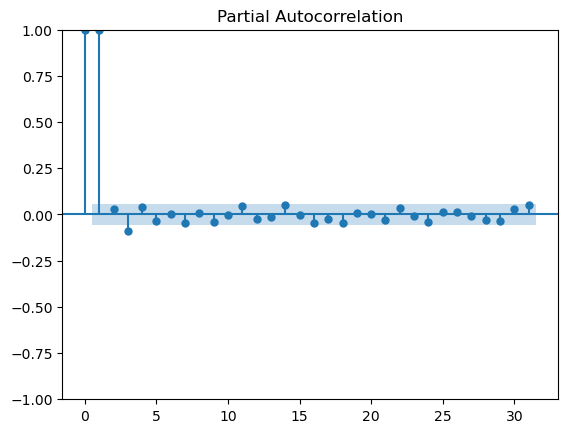

In [54]:
acf12 = plot_pacf(df1["Close"].dropna())

In [55]:
df1.shape

(1233, 7)

In [56]:
### split train and test data
df1.head(3)

,Open,High,Low,Close,Adj Close,Volume,first_diff_Close
Date,,,,,,,
2017-11-15,414.299988,417.549988,407.000000,408.649994,408.649994,9867270,NaN
2017-11-16,411.350006,415.899994,411.350006,413.450012,413.450012,6291441,4.800018
2017-11-17,419.450012,423.450012,417.000000,421.799988,421.799988,6191428,8.349976


In [57]:
df1.tail(3)

,Open,High,Low,Close,Adj Close,Volume,first_diff_Close
Date,,,,,,,
2022-11-09,439.200012,441.200012,432.000000,433.149994,433.149994,14471443,-1.850006
2022-11-10,420.500000,420.549988,409.200012,412.200012,412.200012,26251660,-20.949982
2022-11-11,420.000000,425.500000,414.700012,423.500000,423.500000,19296401,11.299988


<AxesSubplot:xlabel='Date'>

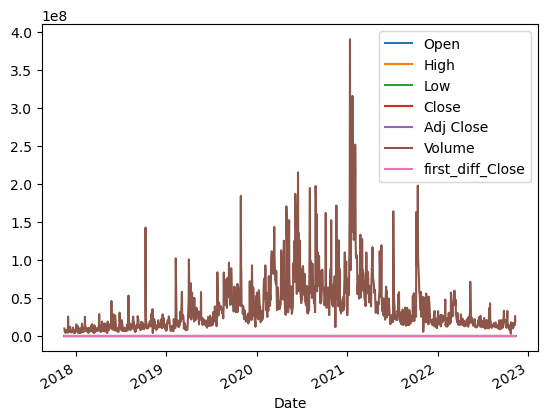

In [58]:
df1.plot()

In [59]:
from datetime import datetime,timedelta
train_dataset_end=datetime(2021,12,1)
test_dataset_end=datetime(2022,11,11)


In [60]:
train_data=df1[:train_dataset_end]
test_data=df1[train_dataset_end+timedelta(days=1):test_dataset_end]

In [61]:
train_data

,Open,High,Low,Close,Adj Close,Volume,first_diff_Close
Date,,,,,,,
2017-11-15,414.299988,417.549988,407.000000,408.649994,408.649994,9867270,NaN
2017-11-16,411.350006,415.899994,411.350006,413.450012,413.450012,6291441,4.800018
2017-11-17,419.450012,423.450012,417.000000,421.799988,421.799988,6191428,8.349976
2017-11-20,421.000000,425.700012,420.100006,423.000000,423.000000,4051153,1.200012
2017-11-21,424.450012,430.000000,422.500000,424.250000,424.250000,6745407,1.250000
...,...,...,...,...,...,...,...
2021-11-25,490.799988,495.149994,486.500000,492.750000,492.750000,15336539,4.100006
2021-11-26,486.000000,486.750000,458.000000,460.200012,460.200012,51787989,-32.549988
2021-11-29,457.000000,470.750000,443.100006,461.450012,461.450012,42819150,1.250000


<AxesSubplot:xlabel='Date'>

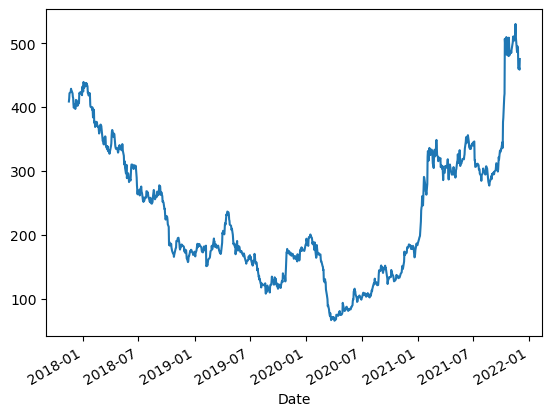

In [62]:
train_data['Close'].plot()

In [63]:
test_data

,Open,High,Low,Close,Adj Close,Volume,first_diff_Close
Date,,,,,,,
2021-12-02,479.399994,480.450012,471.700012,479.100006,479.100006,21012008,3.850006
2021-12-03,480.000000,484.700012,477.299988,480.100006,480.100006,20948900,1.000000
2021-12-06,480.100006,480.899994,466.000000,467.200012,467.200012,17473075,-12.899994
2021-12-07,476.850006,484.899994,471.000000,481.799988,481.799988,21280797,14.599976
2021-12-08,484.500000,495.950012,483.500000,493.899994,493.899994,20581817,12.100006
...,...,...,...,...,...,...,...
2022-11-04,418.200012,426.000000,416.899994,425.350006,425.350006,12277023,9.100006
2022-11-07,428.250000,437.500000,428.250000,435.000000,435.000000,15058076,9.649994
2022-11-09,439.200012,441.200012,432.000000,433.149994,433.149994,14471443,-1.850006


In [64]:
## create a ARIMA model
from statsmodels.tsa.arima.model import ARIMA

In [65]:
model_ARIMA_close=ARIMA(df1['Close'],order=(32,1,5))

C:\Users\BIPLAB\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\BIPLAB\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\BIPLAB\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [66]:
model_Arima_fit_close=model_ARIMA_close.fit()

C:\Users\BIPLAB\anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [67]:
model_Arima_fit_close.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                 1233
Model:                ARIMA(32, 1, 5)   Log Likelihood               -4275.345
Date:                Thu, 22 Dec 2022   AIC                           8626.691
Time:                        14:16:37   BIC                           8821.114
Sample:                             0   HQIC                          8699.833
                               - 1233                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4757      0.961     -0.495      0.621      -2.359       1.408
ar.L2         -0.5427      0.394     -1.378      0.168      -1.315       0.229
ar.L3         -0.1698      0.589     -0.288      0.773      -1.323       0.984
ar.L4         -0.6998      0.209     -3.356      0.001      -1.109      -0.291
ar.L5         -0.2104      0.589     -0.357      0.721      -1.365       0.944
ar.L6          0.0935      0.036      2.632      0.008       0.024       0.163
ar.L7         -0.0204      0.103     -0.197      0.844      -0.223       0.182
ar.L8          0.1231      0.048      2.582      0.010       0.030       0.217
ar.L9          0.0576      0.134      0.429      0.668      -0.206       0.321
ar.L10         0.0293      0.046      0.632      0.528      -0.062       0.120
ar.L11         0.0434      0.046      0.933      0.351      -0.048       0.134
ar.L12         0.0683      0.046      1.480      0.139      -0.022       0.159
ar.L13        -0.0132      0.067     -0.196      0.844      -0.145       0.119
ar.L14        -0.0318      0.049     -0.653      0.514      -0.127       0.064
ar.L15         0.0458      0.052      0.874      0.382      -0.057       0.149
ar.L16         0.0435      0.064      0.684      0.494      -0.081       0.168
ar.L17         0.0333      0.061      0.550      0.582      -0.085       0.152
ar.L18         0.0176      0.058      0.301      0.763      -0.097       0.132
ar.L19         0.0652      0.048      1.350      0.177      -0.029       0.160
ar.L20         0.0479      0.074      0.646      0.518      -0.097       0.193
ar.L21         0.0137      0.055      0.249      0.804      -0.094       0.121
ar.L22         0.0159      0.047      0.339      0.735      -0.076       0.108
ar.L23        -0.0194      0.043     -0.454      0.650      -0.103       0.064
ar.L24        -0.0257      0.047     -0.545      0.586      -0.118       0.067
ar.L25        -0.0443      0.045     -0.983      0.326      -0.133       0.044
ar.L26        -0.0171      0.055     -0.313      0.754      -0.124       0.090
ar.L27         0.0129      0.041      0.314      0.754      -0.068       0.093
ar.L28         0.0155      0.040      0.385      0.701      -0.064       0.095
ar.L29         0.0049      0.037      0.132      0.895      -0.068       0.078
ar.L30        -0.0143      0.044     -0.330      0.742      -0.100       0.071
ar.L31        -0.0346      0.045     -0.772      0.440      -0.123       0.053
ar.L32         0.0265      0.063      0.418      0.676      -0.098       0.151
ma.L1          0.4737      0.959      0.494      0.621      -1.406       2.353
ma.L2          0.5870      0.393      1.494      0.135      -0.183       1.357
ma.L3          0.1198      0.631      0.190      0.849      -1.117       1.356
ma.L4          0.7661      0.200      3.822      0.000       0.373       1.159
ma.L5          0.2106      0.660      0.319      0.750      -1.083       1.504
sigma2        59.8502      1.436     41.689      0.000      57.036      62.664
==

In [68]:
test_data

,Open,High,Low,Close,Adj Close,Volume,first_diff_Close
Date,,,,,,,
2021-12-02,479.399994,480.450012,471.700012,479.100006,479.100006,21012008,3.850006
2021-12-03,480.000000,484.700012,477.299988,480.100006,480.100006,20948900,1.000000
2021-12-06,480.100006,480.899994,466.000000,467.200012,467.200012,17473075,-12.899994
2021-12-07,476.850006,484.899994,471.000000,481.799988,481.799988,21280797,14.599976
2021-12-08,484.500000,495.950012,483.500000,493.899994,493.899994,20581817,12.100006
...,...,...,...,...,...,...,...
2022-11-04,418.200012,426.000000,416.899994,425.350006,425.350006,12277023,9.100006
2022-11-07,428.250000,437.500000,428.250000,435.000000,435.000000,15058076,9.649994
2022-11-09,439.200012,441.200012,432.000000,433.149994,433.149994,14471443,-1.850006


In [69]:
##prediction
pred_start_date=test_data.index[0]
pred_end_date=test_data.index[-1]
print(pred_start_date)
print(pred_end_date)

2021-12-02 00:00:00
2022-11-11 00:00:00


In [70]:
pred=model_Arima_fit_close.predict(start=pred_start_date,end=pred_end_date)
residuals=test_data['Close']-pred

In [71]:
pred

Date
2021-12-02    473.368020
2021-12-03    484.006570
2021-12-06    474.997938
2021-12-07    464.987553
2021-12-08    482.298955
                 ...    
2022-11-04    413.177212
2022-11-07    424.299963
2022-11-09    438.111634
2022-11-10    434.037948
2022-11-11    413.438417
Name: predicted_mean, Length: 235, dtype: float64

In [72]:
residuals

Date
2021-12-02     5.731986
2021-12-03    -3.906564
2021-12-06    -7.797926
2021-12-07    16.812435
2021-12-08    11.601039
                ...    
2022-11-04    12.172794
2022-11-07    10.700037
2022-11-09    -4.961640
2022-11-10   -21.837936
2022-11-11    10.061583
Length: 235, dtype: float64

<AxesSubplot:ylabel='Density'>

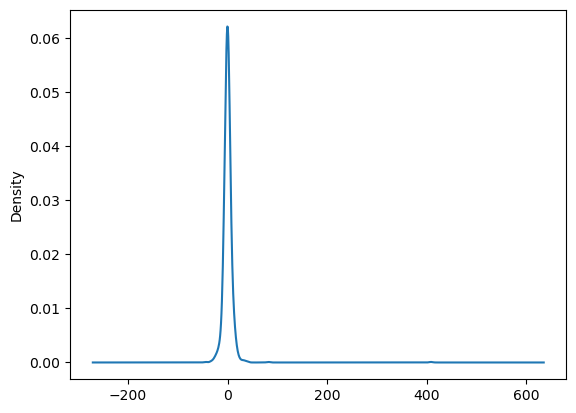

In [73]:
model_Arima_fit_close.resid.plot(kind='kde')

In [74]:
test_data['Predicted_ARIMA_close']=pred

C:\Users\BIPLAB\AppData\Local\Temp\ipykernel_9572\4048640912.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['Predicted_ARIMA_close']=pred


<AxesSubplot:xlabel='Date'>

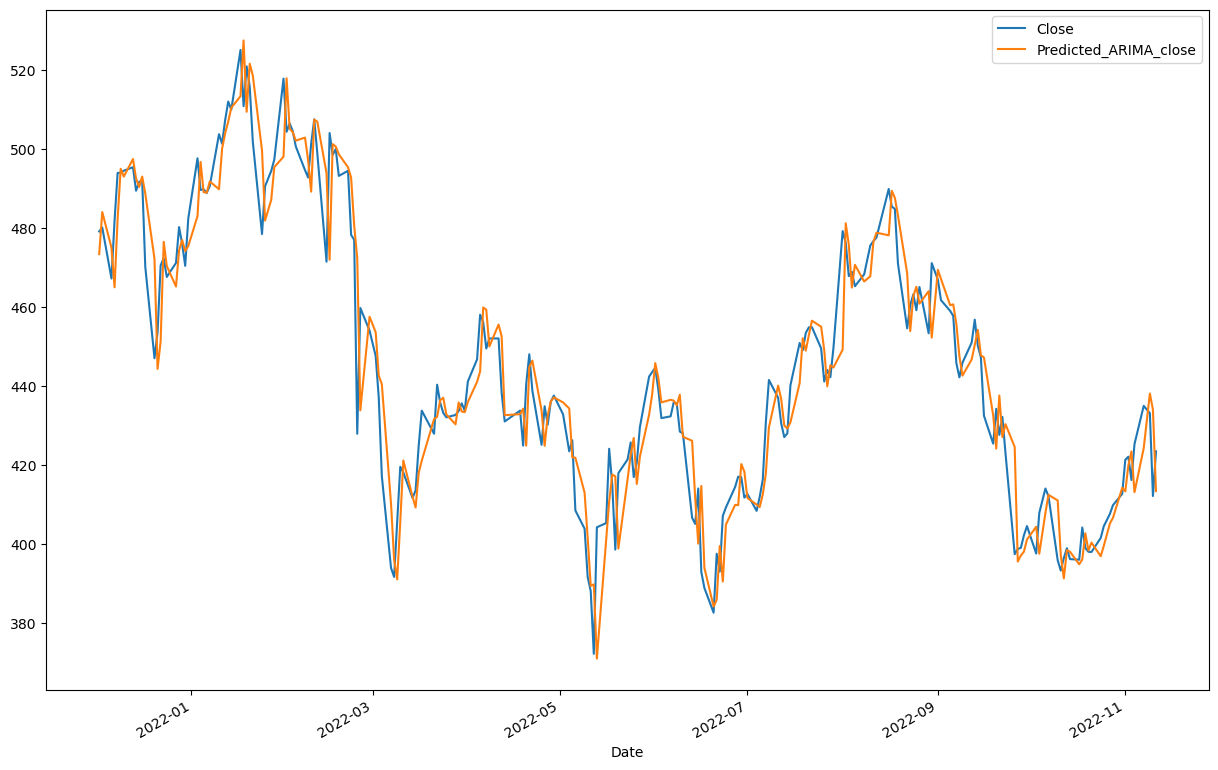

In [75]:
test_data[['Close','Predicted_ARIMA_close']].plot(figsize=(15,10))

In [76]:
pred

Date
2021-12-02    473.368020
2021-12-03    484.006570
2021-12-06    474.997938
2021-12-07    464.987553
2021-12-08    482.298955
                 ...    
2022-11-04    413.177212
2022-11-07    424.299963
2022-11-09    438.111634
2022-11-10    434.037948
2022-11-11    413.438417
Name: predicted_mean, Length: 235, dtype: float64

In [77]:
from sklearn.metrics import mean_squared_error
from math import sqrt

In [78]:
mse= mean_squared_error(pred,test_data['Close'])
mse

99.37353927906175

In [79]:
rmse= sqrt(mean_squared_error(pred,test_data['Close']))
rmse

9.968627753059181

In [80]:
test_data['Close'].mean()
# as rmse is very lesser than mean then our model is a good model

445.3608511404254

In [81]:
##prediction
pred_start_date=test_data.index[-1]
pred_end_date='2023-02-20 00:00:00'
print(pred_start_date)
print(pred_end_date)

2022-11-11 00:00:00
2023-02-20 00:00:00


In [147]:
index_future_dates = pd.date_range(start='2022-11-11',end='2022-12-20')
pred1=model_Arima_fit_close.predict(start=len(df1),end=len(df1)+39)
pred1.index=index_future_dates
# residuals1=test_data['Close']-pred1

C:\Users\BIPLAB\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [148]:
pred1

2022-11-11    423.356533
2022-11-12    423.995702
2022-11-13    422.147408
2022-11-14    423.947940
2022-11-15    423.989715
2022-11-16    423.958489
2022-11-17    422.313707
2022-11-18    424.990356
2022-11-19    425.983790
2022-11-20    423.698233
2022-11-21    424.155865
2022-11-22    426.114661
2022-11-23    425.387489
2022-11-24    424.641940
2022-11-25    424.702223
2022-11-26    424.726121
2022-11-27    425.261778
2022-11-28    424.195880
2022-11-29    423.966559
2022-11-30    425.113464
2022-12-01    424.001619
2022-12-02    424.129655
2022-12-03    425.158644
2022-12-04    424.932687
2022-12-05    425.240761
2022-12-06    424.697010
2022-12-07    423.250971
2022-12-08    424.527612
2022-12-09    425.182955
2022-12-10    425.049554
2022-12-11    424.977392
2022-12-12    424.759669
2022-12-13    423.915262
2022-12-14    424.472205
2022-12-15    424.640726
2022-12-16    424.654560
2022-12-17    425.086836
2022-12-18    424.563545
2022-12-19    424.213367
2022-12-20    424.826694


<AxesSubplot:>

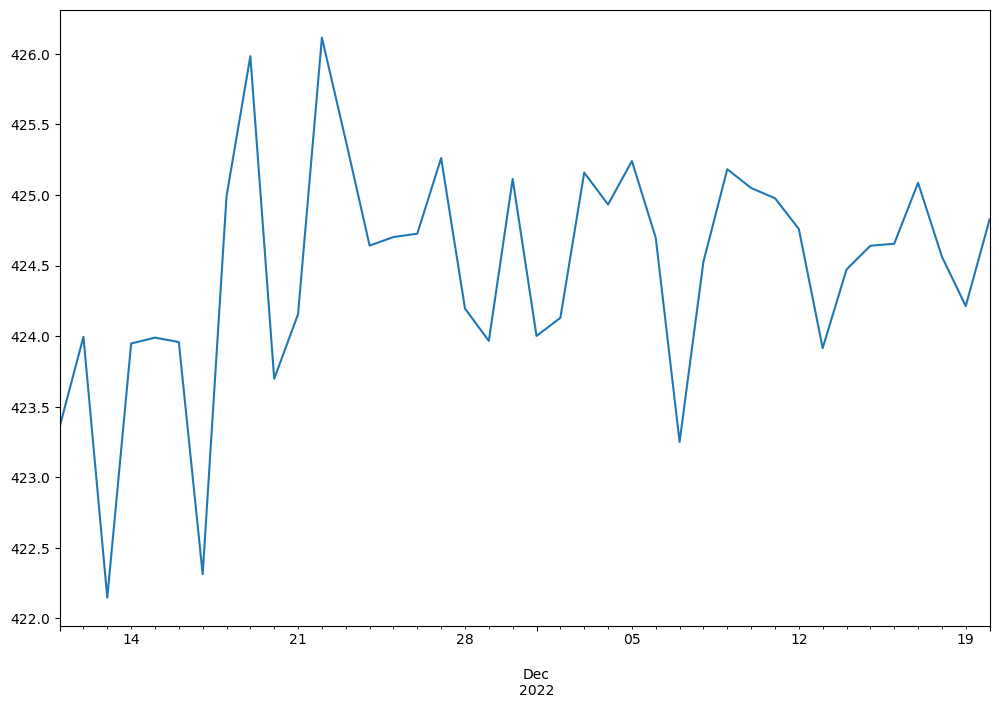

In [149]:
pred1.plot()

In [150]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [151]:
print('r2_score', r2_score(test_data['Close'],pred))

r2_score 0.9171949819744671


In [152]:
df=df.iloc[1000:,:]

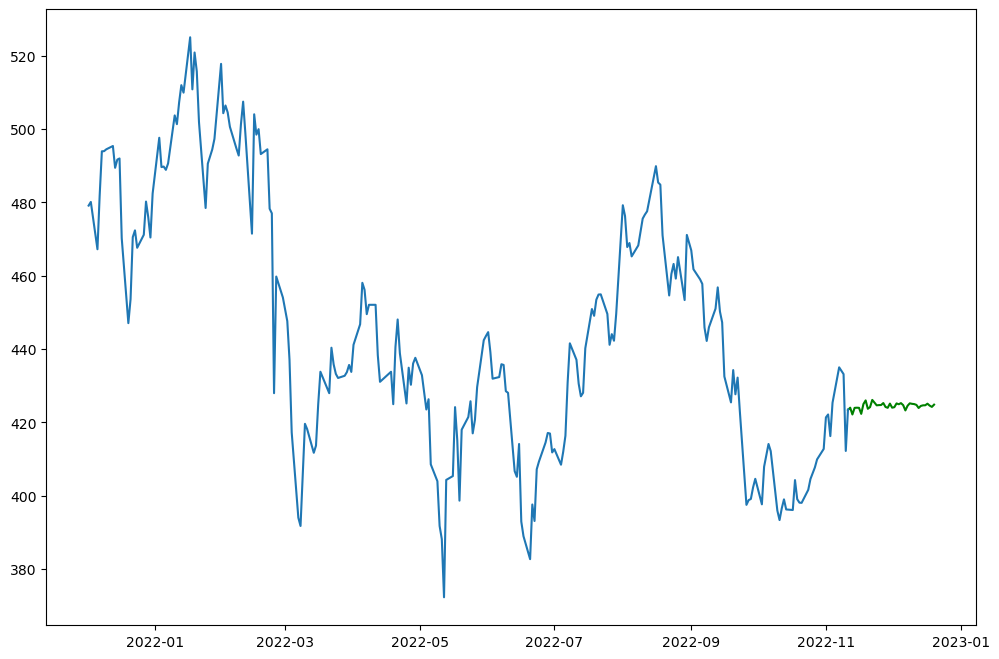

In [153]:
#plt.plot(df)
plt.plot(pred1, color='green')
plt.plot(test_data['Close'])

In [87]:
df

,Open,High,Low,Close,Adj Close,Volume,Close:2 days rolling,Close:5 days rolling,Close:7 days rolling,Close:10 days rolling,Close:30 days rolling,Close:50 days rolling,EMA_0.1,EMA_0.3
Date,,,,,,,,,,,,,,
2017-11-15,414.299988,417.549988,407.000000,408.649994,408.649994,9867270,NaN,NaN,NaN,NaN,NaN,NaN,408.649994,408.649994
2017-11-16,411.350006,415.899994,411.350006,413.450012,413.450012,6291441,411.050003,NaN,NaN,NaN,NaN,NaN,409.129996,410.089999
2017-11-17,419.450012,423.450012,417.000000,421.799988,421.799988,6191428,417.625000,NaN,NaN,NaN,NaN,NaN,410.396995,413.602996
2017-11-20,421.000000,425.700012,420.100006,423.000000,423.000000,4051153,422.399994,NaN,NaN,NaN,NaN,NaN,411.657296,416.422097
2017-11-21,424.450012,430.000000,422.500000,424.250000,424.250000,6745407,423.625000,418.229999,NaN,NaN,NaN,NaN,412.916566,418.770468
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-04,418.200012,426.000000,416.899994,425.350006,425.350006,12277023,420.800003,419.570001,416.492859,411.964999,406.253334,424.079001,411.659894,418.252103
2022-11-07,428.250000,437.500000,428.250000,435.000000,435.000000,15058076,430.175003,424.020001,420.392857,415.660001,406.346666,423.515001,413.993905,423.276472
2022-11-09,439.200012,441.200012,432.000000,433.149994,433.149994,14471443,434.074997,426.379999,423.714286,418.814999,406.681666,422.994000,415.909513,426.238529


In [88]:
df.dropna(inplace=True)
df

,Open,High,Low,Close,Adj Close,Volume,Close:2 days rolling,Close:5 days rolling,Close:7 days rolling,Close:10 days rolling,Close:30 days rolling,Close:50 days rolling,EMA_0.1,EMA_0.3
Date,,,,,,,,,,,,,,
2018-01-24,416.000000,416.250000,402.649994,403.600006,403.600006,10789570,410.800003,416.100000,417.907144,422.955002,423.033334,418.999000,422.411007,416.033071
2018-01-25,403.450012,407.649994,398.000000,400.299988,400.299988,16312167,401.949997,412.369995,414.821429,419.510001,422.978334,418.832000,420.199905,411.313146
2018-01-29,402.500000,405.899994,398.100006,399.250000,399.250000,5789602,399.774994,408.609998,411.435713,415.725000,422.873334,418.548000,418.104915,407.694202
2018-01-30,400.000000,402.299988,395.000000,395.850006,395.850006,6963005,397.550003,403.400000,408.135712,412.075000,422.565000,418.029000,415.879424,404.140943
2018-01-31,395.500000,400.950012,395.250000,399.500000,399.500000,5111454,397.675003,399.700000,405.485713,409.835001,422.355001,417.559000,414.241482,402.748660
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-04,418.200012,426.000000,416.899994,425.350006,425.350006,12277023,420.800003,419.570001,416.492859,411.964999,406.253334,424.079001,411.659894,418.252103
2022-11-07,428.250000,437.500000,428.250000,435.000000,435.000000,15058076,430.175003,424.020001,420.392857,415.660001,406.346666,423.515001,413.993905,423.276472
2022-11-09,439.200012,441.200012,432.000000,433.149994,433.149994,14471443,434.074997,426.379999,423.714286,418.814999,406.681666,422.994000,415.909513,426.238529


In [89]:
from sklearn.metrics import mean_squared_error
from math import sqrt

In [90]:
rmse_2days= sqrt(mean_squared_error(df['Close:2 days rolling'],df['Close']))
rmse_2days

4.032042982911794

In [91]:
print('r2_score', r2_score(df['Close'],df['Close:2 days rolling']))

r2_score 0.9989855784898031


In [92]:
rmse_5days= sqrt(mean_squared_error(df['Close:5 days rolling'],df['Close']))
rmse_5days

8.786469804013482

In [93]:
rmse_7days= sqrt(mean_squared_error(df['Close:5 days rolling'],df['Close']))
rmse_7days

8.786469804013482

In [94]:
rmse_10days= sqrt(mean_squared_error(df['Close:10 days rolling'],df['Close']))
rmse_10days

13.830674657651535

In [95]:
rmse_30days= sqrt(mean_squared_error(df['Close:30 days rolling'],df['Close']))
rmse_30days

27.71735351525462

In [96]:
rmse_50days= sqrt(mean_squared_error(df['Close:50 days rolling'],df['Close']))
rmse_50days

37.06883556049632

In [97]:
rmse_EMA01 = sqrt(mean_squared_error(df['EMA_0.1'],df['Close']))
rmse_EMA01

18.01914507133906

In [98]:
rmse_EMA_03= sqrt(mean_squared_error(df['EMA_0.3'],df['Close']))
rmse_EMA_03

7.995720223136872

In [99]:
df2=pd.read_csv('TATAMOTORS_data.csv')

df2.set_index('Date', inplace=True)

df2.index = pd.to_datetime(df2.index, format = '%Y/%m/%d')

In [100]:
df2=df2.iloc[:,:4]

In [101]:
df2.head()

,Open,High,Low,Close
Date,,,,
2017-11-15,414.299988,417.549988,407.000000,408.649994
2017-11-16,411.350006,415.899994,411.350006,413.450012
2017-11-17,419.450012,423.450012,417.000000,421.799988
2017-11-20,421.000000,425.700012,420.100006,423.000000
2017-11-21,424.450012,430.000000,422.500000,424.250000


x=np.array(df2.index).reshape(-1,1)
y=df2['Close']

In [102]:
x = df2.iloc[:, :-1]
y = df2.iloc[:, -1]

In [103]:
x

,Open,High,Low
Date,,,
2017-11-15,414.299988,417.549988,407.000000
2017-11-16,411.350006,415.899994,411.350006
2017-11-17,419.450012,423.450012,417.000000
2017-11-20,421.000000,425.700012,420.100006
2017-11-21,424.450012,430.000000,422.500000
...,...,...,...
2022-11-04,418.200012,426.000000,416.899994
2022-11-07,428.250000,437.500000,428.250000
2022-11-09,439.200012,441.200012,432.000000


In [104]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)

# Linear Reression

In [105]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(x_train, y_train)

y_pred_test = lr.predict(x_test)

In [106]:
lr.coef_

array([-0.53693132,  0.82135416,  0.71413662])

In [107]:
lr.intercept_

-0.33245548116246937

In [108]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('MAE', mean_absolute_error(y_test,y_pred_test))
print('MSE', mean_squared_error(y_test,y_pred_test))
print('RMSE', np.sqrt(mean_squared_error(y_test,y_pred_test)))
print('r2_score', r2_score(y_test,y_pred_test))

MAE 1.7215232090571375
MSE 5.977788562236945
RMSE 2.444951648241115
r2_score 0.9996577133549309


# SVR

In [109]:
from sklearn.svm import SVR
regressor = SVR(kernel = 'rbf')
regressor.fit(x_train, y_train)

SVR()

In [110]:
y_pred_test_svm = regressor.predict(x_test)

In [111]:
print('MAE', mean_absolute_error(y_test,y_pred_test_svm))
print('MSE', mean_squared_error(y_test,y_pred_test_svm))
print('RMSE', np.sqrt(mean_squared_error(y_test,y_pred_test_svm)))
print('r2_score', r2_score(y_test,y_pred_test_svm))

MAE 13.92447133229416
MSE 629.7053805331035
RMSE 25.093931149445346
r2_score 0.9639432308719973


# Decision Tree

In [112]:
from sklearn.tree import DecisionTreeRegressor
regressor_dt = DecisionTreeRegressor(random_state = 0)
regressor_dt.fit(x, y)

DecisionTreeRegressor(random_state=0)

In [113]:
y_pred_test_dt = regressor_dt.predict(x_test)

In [114]:
print('MAE', mean_absolute_error(y_test,y_pred_test_dt))
print('MSE', mean_squared_error(y_test,y_pred_test_dt))
print('RMSE', np.sqrt(mean_squared_error(y_test,y_pred_test_dt)))
print('r2_score', r2_score(y_test,y_pred_test_dt))

MAE 0.0
MSE 0.0
RMSE 0.0
r2_score 1.0


# Random Forest

In [115]:
from sklearn.ensemble import RandomForestRegressor
regressor_rf = RandomForestRegressor(n_estimators = 80, random_state = 0)
regressor_rf.fit(x, y)

RandomForestRegressor(n_estimators=80, random_state=0)

In [116]:
y_pred_test_rf = regressor_rf.predict(x_test)

In [117]:
print('MAE', mean_absolute_error(y_test,y_pred_test_rf))
print('MSE', mean_squared_error(y_test,y_pred_test_rf))
print('RMSE', np.sqrt(mean_squared_error(y_test,y_pred_test_rf)))
print('r2_score', r2_score(y_test,y_pred_test_rf))

MAE 0.9000959308704573
MSE 1.7718811764529359
RMSE 1.3311202712200487
r2_score 0.9998985425367534


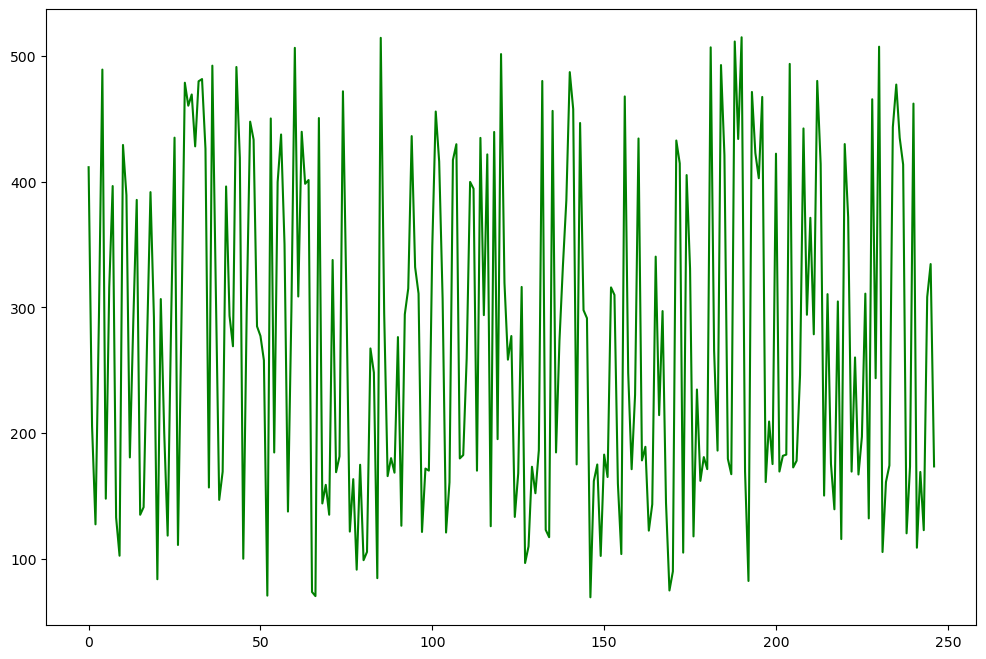

In [154]:
#plt.rcParams["figure.figsize"] = (12,8)
#plt.plot(y_pred_test_rf,label='Random_Forest_Predictions')
#plt.plot(y_test,label='Actual Sales')
#plt.legend(loc="upper left")
#plt.show()

plt.plot(y_pred_test_rf, color='green')
#plt.plot(df2['Close'])